# Mikolov et al. (2013): word2vec (skip-gram + hierarchical softmax), from scratch

This notebook rebuilds **skip-gram with hierarchical softmax** from **Mikolov, Chen, Corrado & Dean (2013),
*Efficient Estimation of Word Representations in Vector Space*** in plain NumPy, trains it on the first 2 million words
of Wikipedia (the `text8` dump), and then checks what the vectors learned.

**The one-sentence idea of the paper:** Bengio's model (notebook 01) learned good word vectors, but most of its cost went into a
hidden layer and a softmax over the whole vocabulary. Throw the hidden layer away, predict *neighbouring* words straight from one
word's vector, and replace the $V$-way softmax with a tree of about $\log_2 V$ yes/no questions. The model gets simple and cheap enough
to train on billions of words, and on that much data the vectors turn out to encode relationships like $\text{king} - \text{man} + \text{woman} \approx \text{queen}$.

**What we will find:**
1. A full softmax costs one dot product per vocabulary word *per training pair*. We time it and see it would take more than a day on our data.
2. A **Huffman tree** cuts each prediction from 21,681 scores to about 10 on average, and it still defines a proper probability distribution.
   We check that the probabilities add up to exactly 1.
3. After one pass over ~11M training pairs, nearest neighbours already make sense (`france` → other countries, `three` → other numbers).
4. Analogies are harder. We can see which ones work at this data size and which don't.

A glossary of every term is at the bottom. Terms appear in **bold** where they are first explained.

## 0. Setup

In [1]:
import collections
import heapq
import os
import random
import time
import urllib.request
import zipfile

import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "data"                      # relative to this notebook; git-ignored
TEXT8 = os.path.join(DATA_DIR, "text8")

## 1. Corpus and vocabulary

- **text8**: the first 100 MB of an English Wikipedia dump, cleaned down to lowercase letters and spaces. Numbers are spelled out
  (`1984` becomes `one nine eight four`), so there is no punctuation and no sentence boundaries: it is one long stream of 17M words.
  We keep the first **2M words** so training finishes in minutes on a laptop.
- **Vocabulary**: the distinct words we give vectors to. Words seen fewer than `MIN_COUNT = 5` times are dropped. There isn't enough
  evidence to learn a vector for them, and they make up most of the distinct words.
- Word IDs are assigned in **frequency order**: ID 0 is the most common word. The Huffman tree in Section 5 needs the frequencies, so we keep them in `freq`.

In [2]:
if not os.path.exists(TEXT8):          # first run only, ~31 MB zip
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path = os.path.join(DATA_DIR, "text8.zip")
    urllib.request.urlretrieve("http://mattmahoney.net/dc/text8.zip", zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)

with open(TEXT8) as f:
    words = f.read().split()
print(f"text8: {len(words):,} words")

words = words[:2_000_000]
print("first 20:", " ".join(words[:20]))

MIN_COUNT = 5
counts = collections.Counter(words)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]   # ID 0 = most frequent
word2id = {w: i for i, w in enumerate(vocab)}
freq = [counts[w] for w in vocab]                                 # freq[i] = count of vocab[i]
V = len(vocab)

corpus = [word2id[w] for w in words if w in word2id]
print(f"\ndistinct words: {len(counts):,}   kept (count >= {MIN_COUNT}): {V:,}")
print(f"corpus after dropping rare words: {len(corpus):,} tokens ({len(corpus) / len(words):.1%} of the text)")
print("most common:", [(w, counts[w]) for w in vocab[:8]])

text8: 17,005,207 words
first 20: anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english



distinct words: 78,382   kept (count >= 5): 21,681
corpus after dropping rare words: 1,910,050 tokens (95.5% of the text)
most common: [('the', 125686), ('of', 72740), ('one', 52394), ('and', 49447), ('in', 44242), ('to', 37033), ('a', 36983), ('zero', 30507)]


Keeping only about a quarter of the distinct words still keeps over 95% of the text. This is **Zipf's law**: a few words are extremely
common and most words are rare. The same skew is what makes the Huffman tree in Section 5 work so well.

Rare words are removed *before* we build training pairs, so the words on either side of a dropped word become neighbours.
The original C implementation does the same.

## 2. Skip-gram: training pairs from a sliding window

Bengio's model read the *previous* $n-1$ words and predicted the next one. word2vec drops the idea of "previous" altogether and works with a
**context window**: the words within $c$ positions on *either* side of a word. The paper proposes two ways to use it:

- **CBOW** (continuous bag-of-words): average the vectors of the surrounding words and predict the word in the middle.
- **Skip-gram**: take the word in the middle (the **center** word) and predict *each* surrounding word (a **context** word) from it, one at a time.

We build skip-gram. Every (center, context) pair is one training example, and the objective over a corpus of $T$ words is

$$\frac{1}{T}\sum_{t=1}^{T}\ \sum_{\substack{-c \le j \le c \\ j \ne 0}} \log P(w_{t+j} \mid w_t)$$

which we maximise (equivalently, we minimise its negative, the cross-entropy loss).

**Dynamic window.** The window size isn't fixed. For every center word we draw $R$ uniformly from $1 \ldots c$ (with $c$ = `WINDOW` = 5)
and only use neighbours within $R$. A word 1 position away is inside every possible window; a word 5 away is only inside the widest one.
So close neighbours produce more training pairs than distant ones. The paper describes this as giving less weight to distant words,
because they are usually less related to the center word.

In [3]:
WINDOW = 5
random.seed(0)                 # the window draws are the only use of `random`

def make_pairs(corpus, window):
    pairs, offsets = [], []
    n = len(corpus)
    for i, center in enumerate(corpus):
        R = random.randint(1, window)                  # this word's window size
        for j in range(max(0, i - R), min(n, i + R + 1)):
            if j != i:
                pairs.append((center, corpus[j]))
                offsets.append(abs(j - i))            # only kept for the check below
    return pairs, offsets

pairs, offsets = make_pairs(corpus, WINDOW)
print(f"{len(pairs):,} training pairs  (~{len(pairs) / len(corpus):.2f} per word; a fixed window of 5 would give 10)")
print("first few:", [(vocab[a], vocab[b]) for a, b in pairs[:6]])

11,457,894 training pairs  (~6.00 per word; a fixed window of 5 would give 10)
first few: [('anarchism', 'originated'), ('anarchism', 'as'), ('anarchism', 'a'), ('anarchism', 'term'), ('originated', 'anarchism'), ('originated', 'as')]


**Checking the distance weighting.** If $R$ is uniform on $1 \ldots 5$, a neighbour at distance $d$ is used whenever $R \ge d$, which
happens with probability $(5 - d + 1)/5$. So distance 1 should appear in 100% of positions, distance 5 in 20%.

In [4]:
off = collections.Counter(offsets)
n_pos = 2 * len(corpus)                      # each distance has a slot on both sides of every word
print(" d   pairs        share of slots used   predicted (6-d)/5")
for d in range(1, WINDOW + 1):
    print(f" {d}   {off[d]:>9,}    {off[d] / n_pos:>8.3f}              {(WINDOW - d + 1) / WINDOW:.3f}")
del offsets, off                             # ~11M ints we no longer need

 d   pairs        share of slots used   predicted (6-d)/5
 1   3,820,098       1.000              1.000
 2   3,054,941       0.800              0.800
 3   2,291,072       0.600              0.600
 4   1,527,697       0.400              0.400
 5     764,086       0.200              0.200


## 3. The model: two embedding tables and nothing else

Skip-gram has **no hidden layer**. For a pair (center, context):

1. Look up the center word's **input vector** $h = C[\text{center}]$, a row of the embedding matrix $C$ (shape $[V, D]$, $D = 100$).
2. Score how likely each word is to be the context word, using a second set of vectors (the **output vectors**).

The rows of $C$ are the **word embeddings** we keep at the end. The output vectors are only used during training.

Compare with notebook 01: Bengio's model concatenated several vectors, ran them through a `tanh` hidden layer, and then scored the vocabulary.
Here the model is **log-linear**: the score is a single dot product, and the log-probability is that score minus a normaliser.
The paper's argument is that dropping the non-linearity costs little in quality and makes the model cheap enough to train on far more data.
That extra data makes up for the simpler model.

**Initialisation** (as in the C code): $C$ uniform in $[-0.5/D,\ 0.5/D]$, output vectors all zero. With zero output vectors every score starts at 0,
so the first prediction is exactly uniform.

In [5]:
D = 100
rng = np.random.default_rng(0)

C = (rng.random((V, D)) - 0.5) / D     # input vectors  = the embeddings we keep
W_out = np.zeros((V, D))               # output vectors for the full softmax (Section 4)
print(f"C: {C.shape}   W_out: {W_out.shape}   parameters: {C.size + W_out.size:,}")

C: (21681, 100)   W_out: (21681, 100)   parameters: 4,336,200


## 4. The naive way: a full softmax over all $V$ words

With one output vector $u_w$ per word, the probability that $w$ is a neighbour of the center word is a **softmax**:

$$P(w \mid \text{center}) = \frac{\exp(u_w \cdot h)}{\sum_{w'=1}^{V} \exp(u_{w'} \cdot h)}$$

- **Cross-entropy loss** for one pair: $-\log P(\text{context} \mid \text{center})$.
- **Gradient of the loss w.r.t. the scores**: with $p$ the softmax output and $y$ the one-hot vector of the true context word, it is $p - y$.
  Every word's score gets pushed down in proportion to its probability, and the true word gets pushed up.
- **Stochastic gradient descent (SGD)**: update the parameters after every single pair, with learning rate $\eta$ = `lr`.

The problem is the denominator. **Every** training pair computes $V$ = 21,681 dot products and updates all $V$ output vectors.
We run 2,000 pairs and time it.

In [6]:
lr = 0.025
N_BASE = 2_000
t0 = time.time()
base_loss = 0.0
for i in range(N_BASE):
    center, context = pairs[i]
    h = C[center]
    scores = W_out @ h                               # V dot products
    e = np.exp(scores - scores.max())                # subtracting the max avoids overflow; the softmax is unchanged
    probs = e / e.sum()
    base_loss += -np.log(probs[context])

    err = probs.copy()
    err[context] -= 1                                # p - y
    grad_h = W_out.T @ err                           # must use W_out before it changes
    W_out -= lr * np.outer(err, h)                   # touches all V output vectors
    C[center] -= lr * grad_h
full_sec = (time.time() - t0) / N_BASE

print(f"avg loss over {N_BASE:,} pairs: {base_loss / N_BASE:.3f}   (uniform guess = ln V = {np.log(V):.3f})")
print(f"{full_sec * 1e3:.2f} ms per pair  ->  one pass over {len(pairs):,} pairs ≈ {full_sec * len(pairs) / 3600:.0f} hours")

avg loss over 2,000 pairs: 9.984   (uniform guess = ln V = 9.984)
8.67 ms per pair  ->  one pass over 11,457,894 pairs ≈ 28 hours


The loss is still close to $\ln V$, the value for a uniform guess: 2,000 pairs is nothing. Finishing the job this way would take many hours even on this
small slice of text8, and the paper trains on billions of words. The cost is **linear in $V$**, and that is what the next section removes.

## 5. Hierarchical softmax: a binary tree over the vocabulary

**Hierarchical softmax** (Morin & Bengio, 2005) puts every word at a **leaf** of a binary tree. To get from the root to a word you
make a sequence of left/right turns. Each internal node (a **fork**) gets its own learned vector $v_n$, and the probability of turning
right at fork $n$ is

$$P(\text{right} \mid n, h) = \sigma(v_n \cdot h), \qquad \sigma(x) = \frac{1}{1 + e^{-x}}$$

The **sigmoid** $\sigma$ is a softmax over just two options (right vs left). The probability of a word is the product of the turn
probabilities along its path:

$$P(w \mid \text{center}) = \prod_{k=1}^{L(w)} \sigma(v_{n_k}\cdot h)^{t_k}\,\big(1-\sigma(v_{n_k}\cdot h)\big)^{1-t_k}$$

where $n_1 \ldots n_{L(w)}$ are the forks from root to $w$ and $t_k \in \{0,1\}$ says whether the path turns right. A prediction now costs $L(w)$ dot products instead of $V$.
Section 6 shows that these products still sum to 1 over the vocabulary.

**Which tree?** Mikolov uses a **Huffman tree**, the tree behind **Huffman coding** (the optimal prefix code for compressing text).
It is built bottom-up: repeatedly merge the two least frequent nodes into a new fork whose count is their sum.
Rare words get merged first and end up deep in the tree; frequent words are merged last and sit near the root. Since frequent words are also
the most frequent *targets*, the average path is short.

A **heap** (Python's `heapq`) is a structure that always hands back its smallest item, which is exactly "the two least frequent nodes".

In [7]:
heap = [(freq[i], i) for i in range(V)]    # leaves: node ids 0..V-1 are the words
heapq.heapify(heap)

parent, went_right = {}, {}
next_id = V                                # forks get ids V, V+1, ...
while len(heap) > 1:
    c1, a = heapq.heappop(heap)            # least frequent
    c2, b = heapq.heappop(heap)            # second least frequent
    parent[a], went_right[a] = next_id, 0
    parent[b], went_right[b] = next_id, 1
    heapq.heappush(heap, (c1 + c2, next_id))
    next_id += 1

root = next_id - 1                         # the last fork created
print(f"leaves (words): {V:,}   forks: {next_id - V:,}   (a binary tree with V leaves always has V-1 forks)")

def path_to(word_id):
    # Walk up from the leaf to the root, then reverse so the path reads root -> word.
    nodes, turns = [], []
    node = word_id
    while node != root:
        nodes.append(parent[node])
        turns.append(went_right[node])
        node = parent[node]
    return nodes[::-1], turns[::-1]

# Fork ids run V .. 2V-2; subtracting V gives the row in the fork-vector table.
paths = [(np.array(n) - V, np.array(t)) for n, t in map(path_to, range(V))]

leaves (words): 21,681   forks: 21,680   (a binary tree with V leaves always has V-1 forks)


**Checking the tree.** Frequent words should get short paths and rare words long ones. The number that sets the training cost is the
**frequency-weighted average path length**, because each word is predicted as often as it appears.

In [8]:
L = np.array([len(t) for _, t in paths])
for w in ["the", "of", "france", "king", "queen", vocab[-1]]:
    i = word2id[w]
    print(f"{w:>12}: count {freq[i]:>7,}   path length {L[i]:>2}   code {''.join(map(str, paths[i][1]))}")

f = np.array(freq)
print(f"\nplain average path length        : {L.mean():.2f}")
print(f"frequency-weighted average       : {(L * f).sum() / f.sum():.2f}   <- what training actually pays per pair")
print(f"log2(V) (a perfectly balanced tree): {np.log2(V):.2f}")
print(f"full softmax                      : {V:,}")

         the: count 125,686   path length  4   code 1010
          of: count  72,740   path length  5   code 11010
      france: count     508   path length 12   code 101100010100
        king: count   1,096   path length 11   code 11001000101
       queen: count     233   path length 13   code 1000101100000
     bubalus: count       5   path length 18   code 000000010110011101

plain average path length        : 16.73
frequency-weighted average       : 10.19   <- what training actually pays per pair
log2(V) (a perfectly balanced tree): 14.40
full softmax                      : 21,681


The **code** column is each word's Huffman code: its sequence of turns, 0 = left and 1 = right. The weighted average is *below* $\log_2 V$,
because the tree spends its short paths on the words that come up most. Per pair this is roughly 2,000× less arithmetic than the full softmax
(Section 6 measures the real speed-up, which is smaller because every step also pays Python's per-step overhead).

### The gradient

The loss for one pair is $-\log P(\text{context} \mid \text{center})$. Because $P$ is a product along the path, the log turns it into a sum,
one **binary cross-entropy** term per fork:

$$\mathcal{L} = -\sum_{k} \Big[ t_k \log p_k + (1 - t_k)\log(1 - p_k) \Big], \qquad p_k = \sigma(v_{n_k} \cdot h)$$

Its derivative with respect to each fork's score $v_{n_k}\cdot h$ is simply $p_k - t_k$: the same "prediction minus target" as the full softmax,
one number per fork. From there, by the chain rule:

- $\partial\mathcal{L}/\partial v_{n_k} = (p_k - t_k)\,h$, so only the $L$ forks on the path get updated, not all $V$ output vectors.
- $\partial\mathcal{L}/\partial h = \sum_k (p_k - t_k)\,v_{n_k}$, which updates one row of $C$.

Before trusting this we compare it with a **finite-difference** estimate: nudge each number by $\pm\epsilon$, re-measure the loss, and take the slope.
If the formula is right the two agree to many decimal places.

In [9]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def hs_loss(h, W, rows, turns):
    p = sigmoid(W[rows] @ h)
    return -np.sum(turns * np.log(p) + (1 - turns) * np.log(1 - p))

# a random h and random fork vectors, so the check isn't trivially at 0
g = np.random.default_rng(123)
h_chk = g.normal(size=D)
W_chk = g.normal(size=(V - 1, D)) * 0.1
rows, turns = paths[word2id["france"]]

p = sigmoid(W_chk[rows] @ h_chk)
err = p - turns
grad_h = err @ W_chk[rows]                  # analytic dL/dh
grad_W = np.outer(err, h_chk)               # analytic dL/dv for each fork on the path

eps = 1e-6
num_h = np.array([(hs_loss(h_chk + eps * e, W_chk, rows, turns) - hs_loss(h_chk - eps * e, W_chk, rows, turns)) / (2 * eps)
                  for e in np.eye(D)])
Wp, Wm = W_chk.copy(), W_chk.copy()
Wp[rows[0], 0] += eps; Wm[rows[0], 0] -= eps
num_w = (hs_loss(h_chk, Wp, rows, turns) - hs_loss(h_chk, Wm, rows, turns)) / (2 * eps)

print(f"dL/dh      max |analytic - numeric| = {np.abs(grad_h - num_h).max():.2e}")
print(f"dL/dv[0,0] analytic {grad_W[0, 0]:.6f}   numeric {num_w:.6f}")

dL/dh      max |analytic - numeric| = 2.62e-09
dL/dv[0,0] analytic 0.626002   numeric 0.626002


## 6. Training

One pass (**epoch**) over all pairs, one SGD step per pair:

1. Walk the context word's path: `rows` are its forks, `turns` its code.
2. $p_k = \sigma(v_{n_k}\cdot h)$ for every fork on the path; loss is the binary cross-entropy above.
3. `error = p - turns`, then update the fork vectors on the path and the center word's row of $C$.

Three details:

- **Order of updates.** `grad_h` has to be computed from the fork vectors *before* they are updated, or the gradient mixes old and new values.
- **Learning-rate decay.** `lr` falls linearly from 0.025 to almost 0 over the run (floored at $0.025 \times 10^{-4}$, as in the C code).
  Large early steps move the vectors into roughly the right place, and small late steps stop the last pairs from pulling them around too much.
- **Fresh start.** $C$ is redrawn so the full-softmax steps above don't leak in. Drawing it from the same `rng` (its second draw) keeps the result
  identical to `word2vec.py`.

This is a plain Python loop over ~11M pairs, so it takes several minutes.

In [10]:
C = (rng.random((V, D)) - 0.5) / D
W_fork = np.zeros((V - 1, D))                    # one vector per fork, zero like W_out

N = len(pairs)
REPORT = 500_000
loss_log = []                                    # (pairs seen, avg loss over the last REPORT pairs)
running = 0.0
t0 = time.time()
for i in range(N):
    lr = max(0.025 * (1 - i / N), 0.025 * 1e-4)
    center, context = pairs[i]
    rows, turns = paths[context]

    h = C[center]                                # a view into C; fine because C[center] is updated last
    p = sigmoid(W_fork[rows] @ h)
    running += -np.sum(turns * np.log(p) + (1 - turns) * np.log(1 - p))

    error = p - turns
    grad_h = error @ W_fork[rows]                # before W_fork changes
    W_fork[rows] -= lr * np.outer(error, h)      # fancy indexing: read a copy, write back; rows are unique within a path
    C[center] -= lr * grad_h

    if (i + 1) % REPORT == 0:
        loss_log.append((i + 1, running / REPORT))
        print(f"{i + 1:>10,} pairs   avg loss {running / REPORT:.3f}   lr {lr:.5f}")
        running = 0.0

hs_sec = (time.time() - t0) / N
print(f"\n{time.time() - t0:.0f} s total, {hs_sec * 1e6:.1f} µs per pair  "
      f"({full_sec / hs_sec:.0f}x faster per pair than the full softmax)")

   500,000 pairs   avg loss 6.684   lr 0.02391


 1,000,000 pairs   avg loss 6.616   lr 0.02282


 1,500,000 pairs   avg loss 6.571   lr 0.02173


 2,000,000 pairs   avg loss 6.626   lr 0.02064


 2,500,000 pairs   avg loss 6.719   lr 0.01955


...

 9,500,000 pairs   avg loss 6.730   lr 0.00427


10,000,000 pairs   avg loss 6.796   lr 0.00318


10,500,000 pairs   avg loss 6.824   lr 0.00209


11,000,000 pairs   avg loss 6.788   lr 0.00100



352 s total, 30.7 µs per pair  (283x faster per pair than the full softmax)


### The loss curve

What does the starting loss mean? With all fork vectors at zero, every $p_k = 0.5$, so a word with a path of length $L$ has probability
$2^{-L}$ and loss $L \ln 2$. The first loss is therefore about **the average path length times 0.693**, the hierarchical-softmax version of "uniform guess".

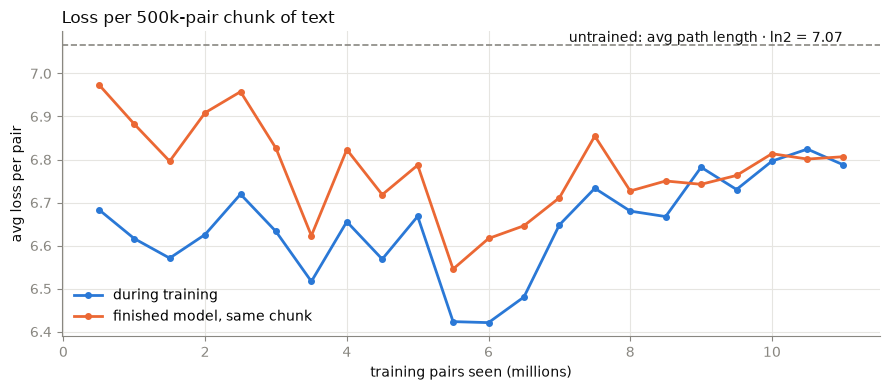

untrained estimate 7.066   first report 6.684   last report 6.788
correlation between the two curves: 0.61
finished model minus training loss, first chunk +0.291   last chunk +0.018


In [11]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e6e5e1"
plt.rcParams.update({"axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "font.size": 10})

start_loss = (L * f).sum() / f.sum() * np.log(2)
x, y = zip(*loss_log)

# The same chunks of text, scored again by the *finished* model (20k random pairs per chunk, no updates).
def pair_loss(center, context):
    rows, turns = paths[context]
    p = sigmoid(W_fork[rows] @ C[center])
    return -np.sum(turns * np.log(p) + (1 - turns) * np.log(1 - p))

pick = np.random.default_rng(1)
final_by_chunk = [np.mean([pair_loss(*pairs[j]) for j in pick.integers(end - REPORT, end, 20_000)]) for end in x]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.array(x) / 1e6, y, color=SERIES[0], lw=2, marker="o", ms=4, label="during training")
ax.plot(np.array(x) / 1e6, final_by_chunk, color=SERIES[1], lw=2, marker="o", ms=4, label="finished model, same chunk")
ax.legend(frameon=False, loc="lower left")
ax.axhline(start_loss, color=MUTED, ls="--", lw=1.2)
ax.text(x[-1] / 1e6, start_loss, f"untrained: avg path length · ln2 = {start_loss:.2f}",
        ha="right", va="bottom", color=INK)
ax.set_xlabel("training pairs seen (millions)")
ax.set_ylabel("avg loss per pair")
ax.set_title("Loss per 500k-pair chunk of text", loc="left", color=INK)
plt.tight_layout()
plt.show()
print(f"untrained estimate {start_loss:.3f}   first report {y[0]:.3f}   last report {y[-1]:.3f}")
print(f"correlation between the two curves: {np.corrcoef(y, final_by_chunk)[0, 1]:.2f}")
print(f"finished model minus training loss, first chunk {final_by_chunk[0] - y[0]:+.3f}   last chunk {final_by_chunk[-1] - y[-1]:+.3f}")

### Reading the curve

The loss falls from the untrained 7.07 to about 6.7 within the first 500k pairs, then **stops improving**. It wanders between 6.4 and 6.8 and ends slightly higher than it started.
That doesn't mean training stopped working. Two things are going on:

1. **The bumps come from the text.** The pairs are processed in corpus order and never shuffled (the C code doesn't shuffle either), so each 500k chunk is a different stretch of
   Wikipedia. Some articles are easier to predict than others. The orange curve scores the *same* chunks with the finished model, and it shows many of the same bumps
   (at 2.5M, 5M and 7.5M pairs; correlation 0.61). So the ups and downs belong to the chunks, not to the training.
2. **The model is best on what it read last.** On the last chunks the two curves agree, but on the first chunks the finished model is *worse* (+0.29) than the model was
   while it was reading them. Plain SGD keeps adjusting the parameters to the current text, and the early articles pull less once the model has moved on.
   The decaying learning rate limits this but doesn't remove it.

The floor is also high for a simpler reason. Predicting which word sits within 5 positions of `france` is very uncertain: dozens of words are plausible,
and no model can know which one comes next. Like the 0.139 floor in notebook 01, much of this loss can't be removed.

**The lesson:** here the training loss is a weak measure of how good the vectors are. What matters is whether similar words ended up with similar vectors,
and that is what Section 7 checks.

### Is it still a probability distribution?

The full softmax divides by a sum, so its outputs add up to 1 by construction. The tree has no such denominator. Here we check directly that it
still does: for one center word, compute $P(w \mid \text{center})$ for **all** 21,681 words by walking each word's path with the trained vectors, and add them up.

It works because at every fork the two branches get $p$ and $1-p$, so the probability flowing into a fork is split between its children without any loss.
Summed over all leaves, the total is the probability that entered at the root, which is 1.

In [12]:
def hs_probs(center_word):
    h = C[word2id[center_word]]
    p_right = sigmoid(W_fork @ h)                 # every fork's P(right) for this center word, computed once
    return np.array([np.prod(np.where(t == 1, p_right[r], 1 - p_right[r])) for r, t in paths])

for cw in ["france", "king"]:
    P = hs_probs(cw)
    top = np.argsort(-P)[:8]
    print(f"center = {cw!r}:  sum over all {V:,} words = {P.sum():.6f}")
    print("   most likely neighbours:", [(vocab[j], round(float(P[j]), 4)) for j in top])

center = 'france':  sum over all 21,681 words = 1.000000
   most likely neighbours: [('of', 0.0728), ('in', 0.0577), ('the', 0.0502), ('and', 0.044), ('one', 0.0338), ('to', 0.0204), ('nine', 0.0159), ('two', 0.0131)]


center = 'king':  sum over all 21,681 words = 1.000000
   most likely neighbours: [('of', 0.1006), ('the', 0.0904), ('and', 0.0289), ('one', 0.0252), ('to', 0.0192), ('a', 0.0184), ('in', 0.0179), ('s', 0.0166)]


The most likely neighbours are mostly frequent function words (`the`, `of`, `and`). That is correct: those really are the words most often found
next to `france`. The *embeddings* capture meaning in a different way, through which words end up with similar vectors, which is what Section 7 looks at.

## 7. What did the vectors learn?

### Reproducibility check

Same seeds, same order of random draws, same data: the vectors should match the ones `word2vec.py` saved, if that file exists. Then we save ours.

In [13]:
saved = os.path.join(DATA_DIR, "C.npy")
if os.path.exists(saved):
    print("matches word2vec.py's data/C.npy:", np.allclose(C, np.load(saved)))
np.save(saved, C)
with open(os.path.join(DATA_DIR, "vocab.txt"), "w") as fh:
    fh.write("\n".join(vocab))

matches word2vec.py's data/C.npy: True


### Nearest neighbours

**Cosine similarity** measures the angle between two vectors, ignoring their length:
$\cos(a, b) = \dfrac{a \cdot b}{\lVert a\rVert\,\lVert b\rVert} \in [-1, 1]$.
If we first scale every row of $C$ to length 1 (**normalising**), cosine is just a dot product, so one matrix-vector product scores the whole vocabulary.

Why should similar words end up close? Two words that appear with the same neighbours have to predict the same context words, i.e. walk the same paths
through the same fork vectors. The cheapest way to do that is to give them similar input vectors. This is the **distributional hypothesis**:
words that appear in similar contexts have similar meanings.

In [14]:
C_unit = C / np.linalg.norm(C, axis=1, keepdims=True)

def nearest(word, k=8):
    sims = C_unit @ C_unit[word2id[word]]
    best = np.argsort(-sims)[1:k + 1]            # [0] is the word itself
    return [(vocab[j], round(float(sims[j]), 3)) for j in best]

for w in ["france", "king", "three", "computer", "war", "red"]:
    print(f"{w:>9} -> {nearest(w)}")

   france -> [('spain', 0.764), ('italy', 0.763), ('provence', 0.723), ('portugal', 0.719), ('toulouse', 0.714), ('cologne', 0.711), ('savoy', 0.702), ('lithuania', 0.7)]


     king -> [('castile', 0.828), ('alfonso', 0.811), ('prince', 0.809), ('trebizond', 0.809), ('afonso', 0.806), ('aragon', 0.793), ('alexius', 0.779), ('emperor', 0.778)]
    three -> [('four', 0.944), ('five', 0.931), ('six', 0.928), ('seven', 0.882), ('eight', 0.862), ('two', 0.851), ('zero', 0.781), ('nine', 0.749)]
 computer -> [('iigs', 0.768), ('design', 0.766), ('computers', 0.76), ('software', 0.735), ('cpu', 0.734), ('hardware', 0.732), ('video', 0.731), ('macintosh', 0.731)]
      war -> [('ii', 0.608), ('battle', 0.591), ('world', 0.587), ('marseille', 0.584), ('vietnam', 0.582), ('during', 0.578), ('civil', 0.555), ('peloponnesian', 0.539)]
      red -> [('cross', 0.67), ('black', 0.646), ('white', 0.595), ('lake', 0.549), ('river', 0.508), ('near', 0.5), ('stockings', 0.481), ('trim', 0.48)]


### What we see

- **Numbers form the tightest cluster** (`three` → `four` 0.94, `five`, `six`, ...). text8 spells every digit out, so `one`, `two`, `three`
  are among the most frequent words in the corpus and appear in near-identical contexts ("*three* hundred", "in *four* years").
- **`france` → `spain`, `italy`, `portugal`**: other countries, the right kind of neighbour. Further down come French places (`provence`, `toulouse`, `savoy`):
  words that share *topic* with `france`, not role.
- **`king` → `castile`, `alfonso`, `aragon`, `prince`, `emperor`.** These are words from the articles `king` appears in (Iberian and Byzantine history).
  With only 1,096 occurrences, a few articles decide what the neighbourhood looks like.
- **`war` → `ii`, `world`, `civil`** and **`red` → `cross`**: fixed phrases ("world war ii", "civil war", "red cross"). Skip-gram rewards words that
  *co-occur*, so collocations land close together even though they don't mean the same thing.

So the vectors mix two kinds of similarity: words that can **replace** each other (three/four, france/spain) and words that **occur together** (war/ii, red/cross).
Both come out of the same objective.

### Analogies: vector arithmetic

The paper's headline result. To answer "*a* is to *b* as *c* is to ?", compute

$$x = \text{vec}(b) - \text{vec}(a) + \text{vec}(c)$$

and return the word whose vector has the highest cosine with $x$, excluding $a$, $b$ and $c$ themselves (otherwise the answer is almost always $b$ or $c$).
If the direction from `man` to `king` roughly equals the direction from `woman` to `queen`, then `king - man + woman` lands near `queen`.

The paper tests this on 19,544 questions, split into **semantic** (capital–country, man–woman, currency) and **syntactic** (plural, comparative, past tense).

In [15]:
def analogy(a, b, c, k=5):
    idx = [word2id[w] for w in (a, b, c)]
    x = C_unit[idx[1]] - C_unit[idx[0]] + C_unit[idx[2]]
    sims = C_unit @ (x / np.linalg.norm(x))
    sims[idx] = -np.inf                          # exclude the question words
    best = np.argsort(-sims)[:k]
    return [(vocab[j], round(float(sims[j]), 3)) for j in best]

tests = [
    ("man", "king", "woman", "queen"),
    ("france", "paris", "italy", "rome"),
    ("france", "paris", "germany", "berlin"),
    ("big", "bigger", "small", "smaller"),
    ("walk", "walking", "swim", "swimming"),
    ("two", "four", "three", "six"),
]
for a, b, c, want in tests:
    got = analogy(a, b, c)
    rank = [w for w, _ in got].index(want) + 1 if want in [w for w, _ in got] else None
    print(f"{a} : {b} :: {c} : ?   want {want!r} -> rank {rank}   {got}")

man : king :: woman : ?   want 'queen' -> rank None   [('epirus', 0.684), ('sancho', 0.682), ('tsar', 0.675), ('elder', 0.673), ('demetrius', 0.671)]
france : paris :: italy : ?   want 'rome' -> rank None   [('strasbourg', 0.657), ('ethelred', 0.642), ('taganrog', 0.634), ('dunfermline', 0.633), ('poitou', 0.627)]
france : paris :: germany : ?   want 'berlin' -> rank 1   [('berlin', 0.583), ('moscow', 0.563), ('brussels', 0.55), ('solzhenitsyn', 0.545), ('january', 0.536)]
big : bigger :: small : ?   want 'smaller' -> rank None   [('safe', 0.699), ('humid', 0.687), ('glaciers', 0.679), ('rapidly', 0.668), ('siliceous', 0.653)]
walk : walking :: swim : ?   want 'swimming' -> rank None   [('bravo', 0.642), ('tripod', 0.589), ('aruban', 0.582), ('elk', 0.571), ('altitude', 0.56)]
two : four :: three : ?   want 'six' -> rank 1   [('six', 0.876), ('seven', 0.874), ('five', 0.868), ('eight', 0.839), ('nine', 0.709)]


Two of six questions are answered correctly: `berlin` and `six`. `six` barely wins (0.876 vs `seven` at 0.874) because every number sits in the same tight cluster,
so treat it as half luck. The rest are wrong, including the famous `king - man + woman`. How often does each word appear?

In [16]:
for a, b, c, want in tests:
    print("   ".join(f"{w:>9} {freq[word2id[w]]:>7,}" for w in (a, b, c, want)))

      man     787        king   1,096       woman     210       queen     233
   france     508       paris     217       italy     205        rome     250
   france     508       paris     217     germany     422      berlin     129
      big     158      bigger      18       small     713     smaller     207
     walk      53     walking      32        swim       7    swimming      14
      two  23,570        four  13,215       three  14,571         six  13,237


### Why most analogies fail here

- **Too little data per word.** An analogy only works if the *offset* $\text{vec}(b) - \text{vec}(a)$ is the same for different word pairs. Each vector has to be
  accurate for that, and the misses involve words seen only a few hundred times (`queen`, `smaller`, `swimming`). Their vectors mostly record which few articles
  they appeared in, not their general role. Near `king` we found medieval names, so `king - man + woman` lands among `epirus`, `sancho` and `tsar`.
- **Frequency isn't the whole story.** Numbers are among the most common words in text8, which explains `six`. But `berlin` (129 occurrences) is *rarer* than `rome` (250), and only `berlin` works. With a few hundred examples per word, whether a given analogy lands is partly luck: it depends on which articles those examples came from.
- **Scale is the paper's point.** Mikolov et al.'s Table 2 shows analogy accuracy rising steadily with both vector size and training words, and even their
  smallest setting uses 24M words, twelve times our 2M, for more than one epoch. Fixing this means more text, more epochs, and in the follow-up paper
  subsampling frequent words and negative sampling. The model itself doesn't need to change.

## Glossary

| term | meaning |
|---|---|
| **analogy (vector)** | answering "a : b :: c : ?" with the word nearest to $\text{vec}(b) - \text{vec}(a) + \text{vec}(c)$ |
| **binary cross-entropy** | $-[t\log p + (1-t)\log(1-p)]$: the loss for one yes/no prediction $p$ with true answer $t \in \{0,1\}$ |
| **CBOW** | continuous bag-of-words: predict the middle word from the average of its neighbours' vectors |
| **center / context word** | in skip-gram, the word we look up (center) and a word within its window that we try to predict (context) |
| **code (Huffman)** | a word's sequence of left/right turns from the root of the tree, written as 0s and 1s |
| **context window** | the words within $c$ positions on either side of the center word |
| **cosine similarity** | $a\cdot b / (\lVert a\rVert \lVert b\rVert)$, the cosine of the angle between two vectors, in $[-1, 1]$ |
| **cross-entropy loss** | $-\log$ of the probability the model gave to the correct answer |
| **distributional hypothesis** | words that occur in similar contexts tend to have similar meanings |
| **dynamic window** | drawing the window size $R \in 1..c$ per center word, so near neighbours produce more pairs than far ones |
| **embedding / input vector** | a row of $C$; the learned vector for a word, and what we keep after training |
| **epoch** | one full pass over the training pairs |
| **finite difference** | estimating a derivative numerically as $(f(x+\epsilon) - f(x-\epsilon))/2\epsilon$, used to check a hand-derived gradient |
| **fork / internal node** | a non-leaf node of the tree; each has a vector $v_n$ that decides left vs right |
| **full softmax** | $\exp(s_w)/\sum_{w'} \exp(s_{w'})$ over the whole vocabulary; costs $O(V)$ per prediction |
| **heap** | a data structure that always returns its smallest item first; used to find the two rarest nodes when building the tree |
| **hierarchical softmax** | replacing the $V$-way softmax with a product of binary decisions along a tree path; costs $O(\log V)$ |
| **Huffman tree / coding** | the binary tree made by repeatedly merging the two least frequent nodes; frequent symbols get short codes |
| **learning-rate decay** | shrinking the step size during training; here linearly from 0.025 to ~0 |
| **log-linear model** | a model whose log-probabilities are linear in its parameters' dot products, with no hidden non-linearity |
| **normalising (a vector)** | dividing it by its length so it has length 1 |
| **output vector** | the second set of vectors used only to score predictions: `W_out` for the full softmax, `W_fork` for the tree |
| **SGD** | stochastic gradient descent: update the parameters after each example (here each pair) instead of after the whole dataset |
| **sigmoid** $\sigma$ | $1/(1+e^{-x})$; maps any number to $(0, 1)$; a softmax over two options |
| **skip-gram** | predict each context word from the center word's vector |
| **text8** | the first $10^8$ characters of a cleaned English Wikipedia dump |
| **Zipf's law** | a word's frequency is roughly inversely proportional to its frequency rank, so a few words dominate the text |